In [1]:
import tensorflow as tf

print("="*80)
print("TensorFlow 및 GPU 확인")
print("="*80)
print(f"TensorFlow 버전: {tf.__version__}")
print(f"CUDA 빌드: {tf.test.is_built_with_cuda()}")
print(f"GPU 목록: {tf.config.list_physical_devices('GPU')}")
print("="*80)

TensorFlow 및 GPU 확인
TensorFlow 버전: 2.12.0
CUDA 빌드: False
GPU 목록: []


In [2]:
# gpu_setup_check.py
import subprocess
import sys

print("="*80)
print("시스템 GPU 환경 확인")
print("="*80)

# NVIDIA GPU 확인
print("\n[1] NVIDIA GPU 확인")
try:
    result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    if result.returncode == 0:
        print(result.stdout)
    else:
        print("nvidia-smi 실행 실패 - NVIDIA 드라이버가 설치되지 않았을 수 있습니다.")
except FileNotFoundError:
    print("nvidia-smi를 찾을 수 없습니다. NVIDIA 드라이버를 설치해주세요.")

# Python 환경 확인
print("\n[2] Python 환경")
print(f"Python 버전: {sys.version}")
print(f"Python 경로: {sys.executable}")

# 설치된 TensorFlow 패키지 확인
print("\n[3] 설치된 TensorFlow 관련 패키지")
try:
    result = subprocess.run([sys.executable, '-m', 'pip', 'list'],
                          capture_output=True, text=True)
    for line in result.stdout.split('\n'):
        if 'tensorflow' in line.lower() or 'cuda' in line.lower():
            print(line)
except Exception as e:
    print(f"패키지 확인 실패: {e}")

print("="*80)

시스템 GPU 환경 확인

[1] NVIDIA GPU 확인
Sat Jan 31 00:41:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 576.52                 Driver Version: 576.52         CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090      WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   38C    P8             22W /  370W |    1006MiB /  24576MiB |      9%      Default |
|                                         |                        |                  N/A |
+--------------

In [3]:
# reinstall_tensorflow_gpu.py
import subprocess
import sys
import os

def run_command(command, description):
    """명령어 실행"""
    print(f"\n{'='*80}")
    print(f"{description}")
    print(f"{'='*80}")

    try:
        result = subprocess.run(command, shell=True, check=True,
                              capture_output=True, text=True)
        print(result.stdout)
        if result.stderr and "WARNING" not in result.stderr:
            print(result.stderr)
        return True
    except subprocess.CalledProcessError as e:
        print(f"오류: {e}")
        if e.stderr:
            print(e.stderr)
        return False

def main():
    print("="*80)
    print("TensorFlow GPU 버전 재설치")
    print("="*80)

    # 1. 기존 TensorFlow 완전 제거
    packages_to_remove = [
        'tensorflow',
        'tensorflow-intel',
        'tensorflow-gpu',
        'tensorflow-estimator'
    ]

    for package in packages_to_remove:
        run_command(
            f'{sys.executable} -m pip uninstall {package} -y',
            f'[1] {package} 제거'
        )

    # 2. pip 업그레이드
    run_command(
        f'{sys.executable} -m pip install --upgrade pip',
        '[2] pip 업그레이드'
    )

    # 3. TensorFlow GPU 버전 설치
    # TensorFlow 2.10+ 부터는 tensorflow 패키지에 GPU 지원 포함
    run_command(
        f'{sys.executable} -m pip install tensorflow==2.15.0',
        '[3] TensorFlow 2.15.0 설치 (GPU 지원 포함)'
    )

    # 4. 설치 확인
    print(f"\n{'='*80}")
    print("[4] 설치 확인")
    print(f"{'='*80}")

    verification_code = """
import tensorflow as tf
print(f"TensorFlow 버전: {tf.__version__}")
print(f"CUDA 빌드: {tf.test.is_built_with_cuda()}")
print(f"GPU 디바이스: {tf.config.list_physical_devices('GPU')}")

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"\\n감지된 GPU 수: {len(gpus)}")
    for i, gpu in enumerate(gpus):
        print(f"  GPU {i}: {gpu}")
    print("\\nGPU 사용 준비 완료!")
else:
    print("\\n경고: GPU를 찾을 수 없습니다.")
"""

    try:
        result = subprocess.run(
            [sys.executable, '-c', verification_code],
            capture_output=True, text=True, timeout=30
        )
        print(result.stdout)
        if result.stderr and "successfully opened dynamic library" not in result.stderr:
            print("경고/오류:")
            print(result.stderr)
    except Exception as e:
        print(f"확인 중 오류: {e}")

    print(f"\n{'='*80}")
    print("재설치 완료")
    print(f"{'='*80}")

if __name__ == "__main__":
    main()

TensorFlow GPU 버전 재설치

[1] tensorflow 제거
Found existing installation: tensorflow 2.12.0
Uninstalling tensorflow-2.12.0:
  Successfully uninstalled tensorflow-2.12.0


[1] tensorflow-intel 제거
Found existing installation: tensorflow-intel 2.12.0
Uninstalling tensorflow-intel-2.12.0:
  Successfully uninstalled tensorflow-intel-2.12.0


[1] tensorflow-gpu 제거


[1] tensorflow-estimator 제거
Found existing installation: tensorflow-estimator 2.12.0
Uninstalling tensorflow-estimator-2.12.0:
  Successfully uninstalled tensorflow-estimator-2.12.0


[2] pip 업그레이드
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 1.8/1.8 MB 48.9 MB/s  0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 25.2
    Uninstalling pip-25.2:
      Successfully uninstalled pip-25.2


[3] TensorFlow 2.15.0 설치 (GPU 지원 포함)
  Using cached tensorflow-2.15.0-cp39-cp39-win_amd64.whl.metadata (3.6 kB)
  Using cached tensorflow_intel-2.15.0-cp39-cp39-

Exception in thread Thread-21:
Traceback (most recent call last):
  File "C:\Users\82108\AppData\Local\Programs\Python\Python39\lib\threading.py", line 973, in _bootstrap_inner
    self.run()
  File "C:\Users\82108\AppData\Local\Programs\Python\Python39\lib\threading.py", line 910, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Users\82108\AppData\Local\Programs\Python\Python39\lib\subprocess.py", line 1479, in _readerthread
    buffer.append(fh.read())
UnicodeDecodeError: 'cp949' codec can't decode byte 0xeb in position 51: illegal multibyte sequence


None
경고/오류:



재설치 완료


In [4]:
# check_cuda_installation.py
import os
import subprocess
import sys

print("="*80)
print("CUDA/cuDNN 설치 확인")
print("="*80)

# 환경 변수 확인
print("\n[1] CUDA 관련 환경 변수")
cuda_vars = ['CUDA_PATH', 'CUDA_HOME', 'CUDA_PATH_V11_8', 'CUDA_PATH_V12_9']
for var in cuda_vars:
    value = os.environ.get(var)
    if value:
        print(f"{var}: {value}")

# nvcc 확인
print("\n[2] NVCC (CUDA 컴파일러) 확인")
try:
    result = subprocess.run(['nvcc', '--version'],
                          capture_output=True, text=True)
    print(result.stdout)
except FileNotFoundError:
    print("nvcc를 찾을 수 없습니다.")
    print("참고: TensorFlow 2.10+ Windows 버전은 CUDA가 없어도 작동할 수 있습니다.")

# nvidia-smi로 호환 CUDA 버전 확인
print("\n[3] 드라이버 지원 CUDA 버전")
try:
    result = subprocess.run(['nvidia-smi'],
                          capture_output=True, text=True)
    for line in result.stdout.split('\n'):
        if 'CUDA Version' in line:
            print(line.strip())
except:
    pass

print("\n" + "="*80)
print("참고사항")
print("="*80)
print("""
TensorFlow 2.10 이상 Windows 버전:
- CUDA/cuDNN이 pip 패키지에 포함되어 있습니다
- 별도의 CUDA Toolkit 설치가 필수는 아닙니다
- NVIDIA 드라이버만 최신 상태면 GPU를 사용할 수 있습니다

만약 GPU가 인식되지 않는다면:
1. CUDA Toolkit 11.8 설치
   https://developer.nvidia.com/cuda-11-8-0-download-archive
2. cuDNN 8.6 설치 (CUDA 11.x용)
   https://developer.nvidia.com/cudnn
""")
print("="*80)

CUDA/cuDNN 설치 확인

[1] CUDA 관련 환경 변수
CUDA_PATH: C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.8
CUDA_PATH_V11_8: C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.8

[2] NVCC (CUDA 컴파일러) 확인
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2022 NVIDIA Corporation
Built on Wed_Sep_21_10:41:10_Pacific_Daylight_Time_2022
Cuda compilation tools, release 11.8, V11.8.89
Build cuda_11.8.r11.8/compiler.31833905_0


[3] 드라이버 지원 CUDA 버전
| NVIDIA-SMI 576.52                 Driver Version: 576.52         CUDA Version: 12.9     |

참고사항

TensorFlow 2.10 이상 Windows 버전:
- CUDA/cuDNN이 pip 패키지에 포함되어 있습니다
- 별도의 CUDA Toolkit 설치가 필수는 아닙니다
- NVIDIA 드라이버만 최신 상태면 GPU를 사용할 수 있습니다

만약 GPU가 인식되지 않는다면:
1. CUDA Toolkit 11.8 설치
   https://developer.nvidia.com/cuda-11-8-0-download-archive
2. cuDNN 8.6 설치 (CUDA 11.x용)
   https://developer.nvidia.com/cudnn



In [5]:
# reinstall_tensorflow_gpu.py
import subprocess
import sys

def run_pip_command(command, description):
    """pip 명령어 실행"""
    print(f"\n{'='*80}")
    print(f"{description}")
    print(f"{'='*80}")

    result = subprocess.run(
        f'{sys.executable} -m pip {command}',
        shell=True,
        capture_output=True,
        text=True
    )

    print(result.stdout)
    if result.stderr:
        stderr_lines = result.stderr.split('\n')
        # WARNING 메시지 필터링
        important_errors = [line for line in stderr_lines
                          if line and 'WARNING' not in line]
        if important_errors:
            print('\n'.join(important_errors))

    return result.returncode == 0

def main():
    print("="*80)
    print("TensorFlow GPU 버전 재설치 시작")
    print("="*80)
    print(f"Python 경로: {sys.executable}")
    print(f"Python 버전: {sys.version.split()[0]}")

    # 1. 기존 TensorFlow 패키지 제거
    packages = ['tensorflow', 'tensorflow-intel', 'tensorflow-gpu',
                'tensorflow-estimator']

    for pkg in packages:
        run_pip_command(
            f'uninstall {pkg} -y',
            f'[제거] {pkg}'
        )

    # 2. pip 업그레이드
    run_pip_command(
        'install --upgrade pip',
        '[업그레이드] pip'
    )

    # 3. TensorFlow 2.15.0 설치
    success = run_pip_command(
        'install tensorflow==2.15.0',
        '[설치] TensorFlow 2.15.0 (GPU 지원)'
    )

    if not success:
        print("\n설치 실패. tensorflow==2.13.0으로 재시도...")
        run_pip_command(
            'install tensorflow==2.13.0',
            '[대체 설치] TensorFlow 2.13.0'
        )

    # 4. 설치 확인
    print(f"\n{'='*80}")
    print("[확인] TensorFlow GPU 설치 검증")
    print(f"{'='*80}\n")

    verification_script = """
import tensorflow as tf
import os

# 로그 레벨 설정 (INFO 메시지 숨김)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

print("="*80)
print("TensorFlow GPU 확인")
print("="*80)
print(f"TensorFlow 버전: {tf.__version__}")
print(f"CUDA 빌드 여부: {tf.test.is_built_with_cuda()}")

# GPU 디바이스 확인
gpus = tf.config.list_physical_devices('GPU')
print(f"\\n감지된 GPU 수: {len(gpus)}")

if gpus:
    for i, gpu in enumerate(gpus):
        print(f"\\nGPU {i}:")
        print(f"  이름: {gpu.name}")
        print(f"  타입: {gpu.device_type}")

        # GPU 상세 정보
        try:
            details = tf.config.experimental.get_device_details(gpu)
            if details:
                for key, value in details.items():
                    print(f"  {key}: {value}")
        except:
            pass

    # 메모리 설정
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("\\nGPU 메모리 증가 모드: 활성화됨")
    except RuntimeError as e:
        print(f"\\nGPU 메모리 설정 오류: {e}")

    print("\\n" + "="*80)
    print("GPU 사용 준비 완료!")
    print("="*80)
else:
    print("\\n" + "="*80)
    print("경고: GPU를 찾을 수 없습니다")
    print("="*80)
    print("\\n해결 방법:")
    print("1. 시스템 재부팅")
    print("2. CUDA/cuDNN 재설치")
    print("3. TensorFlow 버전 변경 (2.13.0 시도)")
"""

    result = subprocess.run(
        [sys.executable, '-c', verification_script],
        capture_output=True,
        text=True,
        timeout=60
    )

    print(result.stdout)
    if result.stderr:
        # TensorFlow 초기화 메시지 필터링
        stderr_lines = [line for line in result.stderr.split('\n')
                       if line and
                       'successfully opened dynamic library' not in line and
                       'This TensorFlow binary' not in line]
        if stderr_lines:
            print("\n경고 메시지:")
            print('\n'.join(stderr_lines))

    print(f"\n{'='*80}")
    print("재설치 프로세스 완료")
    print(f"{'='*80}")

if __name__ == "__main__":
    main()

TensorFlow GPU 버전 재설치 시작
Python 경로: C:\Users\82108\AppData\Local\Programs\Python\Python39\python.exe
Python 버전: 3.9.10

[제거] tensorflow
Found existing installation: tensorflow 2.15.0
Uninstalling tensorflow-2.15.0:
  Successfully uninstalled tensorflow-2.15.0


[제거] tensorflow-intel
Found existing installation: tensorflow-intel 2.15.0
Uninstalling tensorflow-intel-2.15.0:
  Successfully uninstalled tensorflow-intel-2.15.0


[제거] tensorflow-gpu


[제거] tensorflow-estimator
Found existing installation: tensorflow-estimator 2.15.0
Uninstalling tensorflow-estimator-2.15.0:
  Successfully uninstalled tensorflow-estimator-2.15.0


[업그레이드] pip


[설치] TensorFlow 2.15.0 (GPU 지원)
  Using cached tensorflow-2.15.0-cp39-cp39-win_amd64.whl.metadata (3.6 kB)
  Using cached tensorflow_intel-2.15.0-cp39-cp39-win_amd64.whl.metadata (5.1 kB)
  Using cached tensorflow_estimator-2.15.0-py2.py3-none-any.whl.metadata (1.3 kB)
Using cached tensorflow-2.15.0-cp39-cp39-win_amd64.whl (2.1 kB)
Using cached tensorf

Exception in thread Thread-39:
Traceback (most recent call last):
  File "C:\Users\82108\AppData\Local\Programs\Python\Python39\lib\threading.py", line 973, in _bootstrap_inner
    self.run()
  File "C:\Users\82108\AppData\Local\Programs\Python\Python39\lib\threading.py", line 910, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Users\82108\AppData\Local\Programs\Python\Python39\lib\subprocess.py", line 1479, in _readerthread
    buffer.append(fh.read())
UnicodeDecodeError: 'cp949' codec can't decode byte 0xed in position 97: illegal multibyte sequence


None

경고 메시지:

재설치 프로세스 완료


In [6]:
# test_gpu_performance.py
import tensorflow as tf
import numpy as np
from datetime import datetime
import os

# TensorFlow 로그 레벨 설정
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

print("="*80)
print("GPU 성능 테스트")
print("="*80)

# GPU 확인
gpus = tf.config.list_physical_devices('GPU')
print(f"\n사용 가능한 GPU: {len(gpus)}")
for gpu in gpus:
    print(f"  - {gpu.name}")

if not gpus:
    print("경고: GPU를 찾을 수 없습니다. CPU로 테스트합니다.")

# GPU 메모리 설정
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

def benchmark_matmul(device, size=10000, iterations=5):
    """행렬 곱셈 벤치마크"""
    print(f"\n[{device}] 행렬 곱셈 테스트 ({size}x{size})")

    times = []
    with tf.device(device):
        # 워밍업
        a = tf.random.normal([size, size])
        b = tf.random.normal([size, size])
        _ = tf.matmul(a, b)

        # 실제 측정
        for i in range(iterations):
            start = datetime.now()

            a = tf.random.normal([size, size])
            b = tf.random.normal([size, size])
            c = tf.matmul(a, b)
            _ = c.numpy()  # 동기화

            elapsed = (datetime.now() - start).total_seconds()
            times.append(elapsed)
            print(f"  반복 {i+1}: {elapsed:.4f}초")

    avg_time = sum(times) / len(times)
    print(f"  평균: {avg_time:.4f}초")
    return avg_time

# CPU 테스트
cpu_time = benchmark_matmul('/CPU:0', size=5000)

# GPU 테스트
if gpus:
    gpu_time = benchmark_matmul('/GPU:0', size=5000)
    speedup = cpu_time / gpu_time
    print(f"\n{'='*80}")
    print(f"GPU 속도 향상: {speedup:.2f}배")
    print(f"{'='*80}")

# LSTM 간단 테스트
print(f"\n{'='*80}")
print("LSTM 모델 테스트")
print(f"{'='*80}")

# 샘플 데이터
timesteps = 50
features = 10
samples = 1000

X_train = np.random.randn(samples, timesteps, features).astype(np.float32)
y_train = np.random.randn(samples, 1).astype(np.float32)

# 모델 생성
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, input_shape=(timesteps, features),
                         return_sequences=True),
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("\n모델 구조:")
model.summary()

print("\n학습 시작...")
start = datetime.now()

history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=10,
    validation_split=0.2,
    verbose=1
)

elapsed = (datetime.now() - start).total_seconds()

print(f"\n{'='*80}")
print(f"학습 완료: {elapsed:.2f}초")
print(f"최종 Loss: {history.history['loss'][-1]:.6f}")
print(f"최종 MAE: {history.history['mae'][-1]:.6f}")
print(f"{'='*80}")

# GPU 메모리 사용량 확인 (가능한 경우)
if gpus:
    print("\nGPU 메모리 사용 정보:")
    print("(nvidia-smi에서 확인하세요)")

GPU 성능 테스트

사용 가능한 GPU: 0
경고: GPU를 찾을 수 없습니다. CPU로 테스트합니다.

[/CPU:0] 행렬 곱셈 테스트 (5000x5000)
  반복 1: 0.7280초
  반복 2: 0.5100초
  반복 3: 0.4460초
  반복 4: 0.4550초
  반복 5: 0.4540초
  평균: 0.5186초

LSTM 모델 테스트

모델 구조:
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 50, 64)            19200     
                                                                 
 lstm_1 (LSTM)               (None, 32)                12416     
                                                                 
 dense (Dense)               (None, 16)                528       
                                                                 
 dense_1 (Dense)             (None, 1)                 17        
                                                                 
Total params: 32,161
Trainable params: 32,161
Non-trainable params: 0
____________________________________________

In [7]:
# diagnose_gpu_issue.py
import subprocess
import sys
import os

print("="*80)
print("GPU 인식 문제 진단")
print("="*80)

# 1. TensorFlow 상세 정보
print("\n[1] TensorFlow 설치 정보")
result = subprocess.run(
    [sys.executable, '-m', 'pip', 'show', 'tensorflow'],
    capture_output=True, text=True
)
print(result.stdout)

# 2. CUDA 라이브러리 로딩 확인
print("\n[2] TensorFlow CUDA 라이브러리 로딩 테스트")

cuda_test = """
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '0'  # 모든 로그 출력

import tensorflow as tf

print("TensorFlow 버전:", tf.__version__)
print("CUDA 빌드:", tf.test.is_built_with_cuda())
print("GPU 디바이스:", tf.config.list_physical_devices('GPU'))

# DLL 로딩 확인
print("\\nDLL 로딩 시도...")
try:
    from tensorflow.python.platform import build_info
    print("Build info:", build_info.build_info)
except Exception as e:
    print(f"Build info 오류: {e}")
"""

result = subprocess.run(
    [sys.executable, '-c', cuda_test],
    capture_output=True, text=True
)
print("STDOUT:")
print(result.stdout)
print("\nSTDERR:")
print(result.stderr)

# 3. 환경 변수 확인
print("\n[3] CUDA 관련 환경 변수")
cuda_vars = [
    'CUDA_PATH', 'CUDA_HOME', 'CUDA_PATH_V11_8',
    'PATH', 'LD_LIBRARY_PATH'
]

for var in cuda_vars:
    value = os.environ.get(var, '')
    if var == 'PATH':
        # PATH는 CUDA 관련 부분만 출력
        paths = value.split(';')
        cuda_paths = [p for p in paths if 'cuda' in p.lower()]
        if cuda_paths:
            print(f"\n{var} (CUDA 관련):")
            for p in cuda_paths:
                print(f"  {p}")
    elif value:
        print(f"{var}: {value}")

print("\n" + "="*80)

GPU 인식 문제 진단

[1] TensorFlow 설치 정보
Name: tensorflow
Version: 2.15.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: c:\users\82108\appdata\local\programs\python\python39\lib\site-packages
Requires: tensorflow-intel
Required-by: 


[2] TensorFlow CUDA 라이브러리 로딩 테스트


Exception in thread Thread-43:
Traceback (most recent call last):
  File "C:\Users\82108\AppData\Local\Programs\Python\Python39\lib\threading.py", line 973, in _bootstrap_inner
    self.run()
  File "C:\Users\82108\AppData\Local\Programs\Python\Python39\lib\threading.py", line 910, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Users\82108\AppData\Local\Programs\Python\Python39\lib\subprocess.py", line 1479, in _readerthread
    buffer.append(fh.read())
UnicodeDecodeError: 'cp949' codec can't decode byte 0xeb in position 51: illegal multibyte sequence


STDOUT:
None

STDERR:
2026-01-31 00:50:43.478913: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.



[3] CUDA 관련 환경 변수
CUDA_PATH: C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.8
CUDA_PATH_V11_8: C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.8

PATH (CUDA 관련):
  C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.8\bin
  C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.8\libnvvp



In [8]:
# check_cudnn.py
import os
import sys

print("="*80)
print("cuDNN 설치 확인")
print("="*80)

cuda_path = os.environ.get('CUDA_PATH', '')
if not cuda_path:
    print("CUDA_PATH 환경 변수가 설정되지 않았습니다.")
    sys.exit(1)

print(f"CUDA_PATH: {cuda_path}")

# cuDNN 파일 확인
cudnn_files = {
    'bin': ['cudnn64_8.dll', 'cudnn_ops_infer64_8.dll', 'cudnn_cnn_infer64_8.dll'],
    'include': ['cudnn.h', 'cudnn_version.h'],
    'lib/x64': ['cudnn.lib']
}

print("\ncuDNN 파일 확인:")
all_found = True

for subdir, files in cudnn_files.items():
    dir_path = os.path.join(cuda_path, subdir)
    print(f"\n[{dir_path}]")

    if not os.path.exists(dir_path):
        print(f"  디렉토리 없음")
        all_found = False
        continue

    for file in files:
        file_path = os.path.join(dir_path, file)
        if os.path.exists(file_path):
            print(f"  [O] {file}")
        else:
            print(f"  [X] {file} - 없음")
            all_found = False

print("\n" + "="*80)
if all_found:
    print("cuDNN이 올바르게 설치되어 있습니다.")
else:
    print("cuDNN 파일이 누락되었습니다.")
    print("\n해결 방법:")
    print("1. cuDNN 8.6 다운로드")
    print("   https://developer.nvidia.com/cudnn")
    print("2. CUDA 11.x용 버전 선택")
    print("3. zip 파일 압축 해제 후 내용물을 CUDA 폴더에 복사")
    print(f"   대상: {cuda_path}")
print("="*80)

cuDNN 설치 확인
CUDA_PATH: C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.8

cuDNN 파일 확인:

[C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.8\bin]
  [O] cudnn64_8.dll
  [O] cudnn_ops_infer64_8.dll
  [O] cudnn_cnn_infer64_8.dll

[C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.8\include]
  [O] cudnn.h
  [O] cudnn_version.h

[C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.8\lib/x64]
  [O] cudnn.lib

cuDNN이 올바르게 설치되어 있습니다.


In [9]:
# install_tensorflow_2_10.py
import subprocess
import sys
import os

def run_command(cmd, description):
    """명령어 실행"""
    print(f"\n{'='*80}")
    print(description)
    print(f"{'='*80}")

    result = subprocess.run(
        cmd, shell=True, capture_output=True, text=True,
        encoding='utf-8', errors='ignore'  # 인코딩 오류 방지
    )

    print(result.stdout)
    if result.returncode != 0 and result.stderr:
        print("오류:", result.stderr)

    return result.returncode == 0

def main():
    print("="*80)
    print("TensorFlow 2.10.1 GPU 버전 설치")
    print("="*80)
    print("이 버전은 Windows GPU 지원이 가장 안정적입니다.")

    # 1. 기존 TensorFlow 완전 제거
    packages = [
        'tensorflow',
        'tensorflow-intel',
        'tensorflow-gpu',
        'tensorflow-estimator',
        'keras'
    ]

    for pkg in packages:
        run_command(
            f'{sys.executable} -m pip uninstall {pkg} -y',
            f'[제거] {pkg}'
        )

    # 2. pip 업그레이드
    run_command(
        f'{sys.executable} -m pip install --upgrade pip',
        '[업그레이드] pip'
    )

    # 3. TensorFlow 2.10.1 설치
    run_command(
        f'{sys.executable} -m pip install tensorflow==2.10.1',
        '[설치] TensorFlow 2.10.1'
    )

    # 4. GPU 확인
    print(f"\n{'='*80}")
    print("[검증] GPU 인식 확인")
    print(f"{'='*80}\n")

    test_code = """
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf

print("="*80)
print("TensorFlow GPU 확인")
print("="*80)
print(f"TensorFlow 버전: {tf.__version__}")
print(f"CUDA 빌드: {tf.test.is_built_with_cuda()}")

gpus = tf.config.list_physical_devices('GPU')
print(f"\\n감지된 GPU: {len(gpus)}개")

if gpus:
    for i, gpu in enumerate(gpus):
        print(f"\\nGPU {i}:")
        print(f"  이름: {gpu.name}")
        print(f"  타입: {gpu.device_type}")

    # GPU 메모리 설정
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("\\nGPU 메모리 증가 모드: 활성화")
    except RuntimeError as e:
        print(f"메모리 설정 오류: {e}")

    # 간단한 연산 테스트
    print("\\nGPU 연산 테스트...")
    with tf.device('/GPU:0'):
        a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
        b = tf.constant([[5.0, 6.0], [7.0, 8.0]])
        c = tf.matmul(a, b)
        print(f"연산 결과: {c.numpy()}")

    print("\\n" + "="*80)
    print("GPU 설정 완료!")
    print("="*80)
else:
    print("\\n경고: GPU를 찾을 수 없습니다.")
    print("="*80)
"""

    result = subprocess.run(
        [sys.executable, '-c', test_code],
        capture_output=True, text=True,
        encoding='utf-8', errors='ignore',
        timeout=60
    )

    print(result.stdout)

    if result.stderr:
        # 중요한 오류만 출력
        stderr_lines = result.stderr.split('\n')
        important = [line for line in stderr_lines
                    if 'error' in line.lower()
                    and 'successfully' not in line.lower()]
        if important:
            print("\n오류 메시지:")
            print('\n'.join(important))

    print(f"\n{'='*80}")
    print("설치 완료")
    print(f"{'='*80}")

if __name__ == "__main__":
    main()

TensorFlow 2.10.1 GPU 버전 설치
이 버전은 Windows GPU 지원이 가장 안정적입니다.

[제거] tensorflow
Found existing installation: tensorflow 2.15.0
Uninstalling tensorflow-2.15.0:
  Successfully uninstalled tensorflow-2.15.0


[제거] tensorflow-intel
Found existing installation: tensorflow-intel 2.15.0
Uninstalling tensorflow-intel-2.15.0:
  Successfully uninstalled tensorflow-intel-2.15.0


[제거] tensorflow-gpu


[제거] tensorflow-estimator
Found existing installation: tensorflow-estimator 2.15.0
Uninstalling tensorflow-estimator-2.15.0:
  Successfully uninstalled tensorflow-estimator-2.15.0


[제거] keras
Found existing installation: keras 2.15.0
Uninstalling keras-2.15.0:
  Successfully uninstalled keras-2.15.0


[업그레이드] pip


[설치] TensorFlow 2.10.1
   ---------------------------------------- 0.0/455.9 MB ? eta -:--:--
    --------------------------------------- 10.2/455.9 MB 57.9 MB/s eta 0:00:08
   - -------------------------------------- 16.5/455.9 MB 41.6 MB/s eta 0:00:11
   --- -----------------------------

LSTM 주가 예측 - GPU 버전

사용 가능한 GPU: 0개
1. 데이터 준비
데이터 크기: 1000 일
종가 범위: 9764 ~ 15326

훈련 데이터: 700 일
검증 데이터: 150 일
테스트 데이터: 150 일

X_train shape: (640, 60, 1)
X_val shape: (90, 60, 1)
X_test shape: (90, 60, 1)

2. LSTM 모델 구축

모델 구조:
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_1 (LSTM)               (None, 60, 128)           66560     
                                                                 
 dropout (Dropout)           (None, 60, 128)           0         
                                                                 
 lstm_2 (LSTM)               (None, 60, 64)            49408     
                                                                 
 dropout_1 (Dropout)         (None, 60, 64)            0         
                                                                 
 lstm_3 (LSTM)               (None, 32)                12416     
                        

C:\Users\82108\AppData\Local\Temp\ipykernel_20428\4082782080.py:240: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from current font.
  plt.tight_layout()
C:\Users\82108\AppData\Local\Temp\ipykernel_20428\4082782080.py:240: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from current font.
  plt.tight_layout()
C:\Users\82108\AppData\Local\Temp\ipykernel_20428\4082782080.py:240: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from current font.
  plt.tight_layout()
C:\Users\82108\AppData\Local\Temp\ipykernel_20428\4082782080.py:240: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from current font.
  plt.tight_layout()
C:\Users\82108\AppData\Local\Temp\ipykernel_20428\4082782080.py:240: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from current font.
  plt.tight_layout()
C:\Users\82108\AppData\Local\Temp\ipykernel_20428\4082782080.py:240: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from current font.
  plt.tight_l


그래프 저장: lstm_stock_prediction.png
모델 저장: stock_lstm_model.h5

완료!


C:\Users\82108\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82108\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82108\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82108\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82108\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\pylabtools.py:152: 

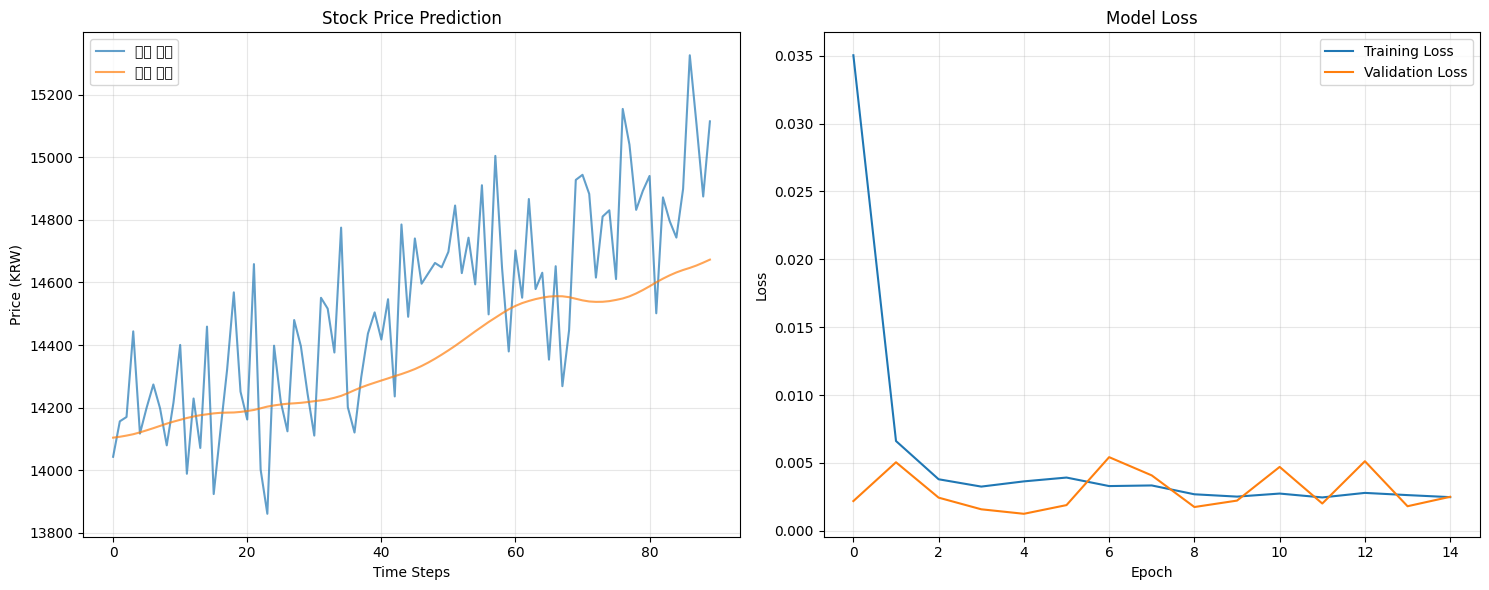

In [11]:
# stock_price_lstm_gpu.py
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
import numpy as np
import pandas as pd
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

print("="*80)
print("LSTM 주가 예측 - GPU 버전")
print("="*80)

# GPU 확인
gpus = tf.config.list_physical_devices('GPU')
print(f"\n사용 가능한 GPU: {len(gpus)}개")
if gpus:
    for gpu in gpus:
        print(f"  - {gpu.name}")
    # 메모리 증가 모드 활성화
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU 메모리 증가 모드: 활성화\n")

# 주가 데이터 생성 함수 (실제로는 DB나 API에서 가져옴)
def create_sample_stock_data(n_days=1000):
    """샘플 주가 데이터 생성"""
    np.random.seed(42)
    dates = pd.date_range(start='2020-01-01', periods=n_days, freq='D')

    # 추세 + 노이즈로 가상 주가 생성
    trend = np.linspace(10000, 15000, n_days)
    seasonality = 500 * np.sin(np.linspace(0, 4*np.pi, n_days))
    noise = np.random.normal(0, 200, n_days)
    price = trend + seasonality + noise

    df = pd.DataFrame({
        'date': dates,
        'close': price
    })

    return df

# 시퀀스 데이터 생성
def create_sequences(data, seq_length):
    """시계열 시퀀스 생성"""
    X, y = [], []

    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])

    return np.array(X), np.array(y)

# 데이터 준비
print("="*80)
print("1. 데이터 준비")
print("="*80)

df = create_sample_stock_data(n_days=1000)
print(f"데이터 크기: {len(df)} 일")
print(f"종가 범위: {df['close'].min():.0f} ~ {df['close'].max():.0f}")

# 정규화
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['close']]).flatten()

# 훈련/검증/테스트 분할
train_size = int(len(scaled_data) * 0.7)
val_size = int(len(scaled_data) * 0.15)

train_data = scaled_data[:train_size]
val_data = scaled_data[train_size:train_size+val_size]
test_data = scaled_data[train_size+val_size:]

print(f"\n훈련 데이터: {len(train_data)} 일")
print(f"검증 데이터: {len(val_data)} 일")
print(f"테스트 데이터: {len(test_data)} 일")

# 시퀀스 생성
SEQ_LENGTH = 60  # 60일 데이터로 다음날 예측

X_train, y_train = create_sequences(train_data, SEQ_LENGTH)
X_val, y_val = create_sequences(val_data, SEQ_LENGTH)
X_test, y_test = create_sequences(test_data, SEQ_LENGTH)

# 3차원으로 reshape (samples, timesteps, features)
X_train = X_train.reshape(-1, SEQ_LENGTH, 1)
X_val = X_val.reshape(-1, SEQ_LENGTH, 1)
X_test = X_test.reshape(-1, SEQ_LENGTH, 1)

print(f"\nX_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")

# LSTM 모델 구축
print("\n" + "="*80)
print("2. LSTM 모델 구축")
print("="*80)

model = tf.keras.Sequential([
    # 첫 번째 LSTM 레이어
    tf.keras.layers.LSTM(
        units=128,
        return_sequences=True,
        input_shape=(SEQ_LENGTH, 1),
        name='lstm_1'
    ),
    tf.keras.layers.Dropout(0.2),

    # 두 번째 LSTM 레이어
    tf.keras.layers.LSTM(
        units=64,
        return_sequences=True,
        name='lstm_2'
    ),
    tf.keras.layers.Dropout(0.2),

    # 세 번째 LSTM 레이어
    tf.keras.layers.LSTM(
        units=32,
        return_sequences=False,
        name='lstm_3'
    ),
    tf.keras.layers.Dropout(0.2),

    # Dense 레이어
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1)
])

# 모델 컴파일
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print("\n모델 구조:")
model.summary()

# 콜백 설정
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=0.00001,
        verbose=1
    )
]

# 모델 학습
print("\n" + "="*80)
print("3. 모델 학습 (GPU 사용)")
print("="*80)

start_time = datetime.now()

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

elapsed_time = (datetime.now() - start_time).total_seconds()

print(f"\n학습 완료 시간: {elapsed_time:.2f}초")

# 모델 평가
print("\n" + "="*80)
print("4. 모델 평가")
print("="*80)

train_loss, train_mae = model.evaluate(X_train, y_train, verbose=0)
val_loss, val_mae = model.evaluate(X_val, y_val, verbose=0)
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)

print(f"\n훈련 세트 - Loss: {train_loss:.6f}, MAE: {train_mae:.6f}")
print(f"검증 세트 - Loss: {val_loss:.6f}, MAE: {val_mae:.6f}")
print(f"테스트 세트 - Loss: {test_loss:.6f}, MAE: {test_mae:.6f}")

# 예측
print("\n" + "="*80)
print("5. 예측 및 시각화")
print("="*80)

predictions = model.predict(X_test, verbose=0)

# 역정규화
predictions_rescaled = scaler.inverse_transform(predictions)
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))

# RMSE 계산
rmse = np.sqrt(np.mean((predictions_rescaled - y_test_rescaled)**2))
print(f"\nRMSE: {rmse:.2f}원")

# 결과 저장
results_df = pd.DataFrame({
    'actual': y_test_rescaled.flatten(),
    'predicted': predictions_rescaled.flatten(),
    'error': y_test_rescaled.flatten() - predictions_rescaled.flatten()
})

print("\n예측 샘플 (최근 10개):")
print(results_df.tail(10).to_string(index=False))

# 시각화
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.plot(y_test_rescaled, label='실제 가격', alpha=0.7)
plt.plot(predictions_rescaled, label='예측 가격', alpha=0.7)
plt.xlabel('Time Steps')
plt.ylabel('Price (KRW)')
plt.title('Stock Price Prediction')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_stock_prediction.png', dpi=150, bbox_inches='tight')
print("\n그래프 저장: lstm_stock_prediction.png")

# 모델 저장
model.save('stock_lstm_model.h5')
print("모델 저장: stock_lstm_model.h5")

print("\n" + "="*80)
print("완료!")
print("="*80)

In [12]:
# gpu_benchmark.py
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
import numpy as np
from datetime import datetime

print("="*80)
print("GPU vs CPU 성능 비교 - LSTM")
print("="*80)

# GPU 설정
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

# 테스트 데이터
samples = 1000
timesteps = 60
features = 1

X = np.random.randn(samples, timesteps, features).astype(np.float32)
y = np.random.randn(samples, 1).astype(np.float32)

# LSTM 모델 생성
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.LSTM(128, return_sequences=True, input_shape=(timesteps, features)),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# CPU 테스트
print("\n[CPU 테스트]")
with tf.device('/CPU:0'):
    model_cpu = create_model()
    start = datetime.now()
    model_cpu.fit(X, y, epochs=10, batch_size=32, verbose=0)
    cpu_time = (datetime.now() - start).total_seconds()
    print(f"학습 시간: {cpu_time:.2f}초")

# GPU 테스트
if gpus:
    print("\n[GPU 테스트]")
    with tf.device('/GPU:0'):
        model_gpu = create_model()
        start = datetime.now()
        model_gpu.fit(X, y, epochs=10, batch_size=32, verbose=0)
        gpu_time = (datetime.now() - start).total_seconds()
        print(f"학습 시간: {gpu_time:.2f}초")

        print(f"\n속도 향상: {cpu_time/gpu_time:.2f}배")

print("="*80)

GPU vs CPU 성능 비교 - LSTM

[CPU 테스트]
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: closure mismatch, requested ('self', 'step_function'), but source function had ()
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: closure mismatch, requested ('self', 'step_function'), but source function had ()
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
학습 시간: 14.12초


In [13]:
# debug_gpu.py
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '0'  # 모든 로그 출력

import tensorflow as tf

print("="*80)
print("GPU 상세 진단")
print("="*80)

print(f"\nTensorFlow 버전: {tf.__version__}")
print(f"CUDA 빌드: {tf.test.is_built_with_cuda()}")

# GPU 디바이스 확인
print("\n[1] 물리적 GPU 디바이스")
physical_gpus = tf.config.list_physical_devices('GPU')
print(f"감지된 GPU: {len(physical_gpus)}개")
for i, gpu in enumerate(physical_gpus):
    print(f"  GPU {i}: {gpu}")

# 논리적 GPU 디바이스 확인
print("\n[2] 논리적 GPU 디바이스")
logical_gpus = tf.config.list_logical_devices('GPU')
print(f"논리적 GPU: {len(logical_gpus)}개")
for i, gpu in enumerate(logical_gpus):
    print(f"  GPU {i}: {gpu}")

# 모든 디바이스 확인
print("\n[3] 모든 디바이스")
devices = tf.config.list_physical_devices()
for device in devices:
    print(f"  {device}")

# GPU 사용 가능 여부 (deprecated지만 확인용)
print(f"\n[4] GPU 사용 가능 (deprecated API): {tf.test.is_gpu_available()}")

# 간단한 연산 테스트
print("\n[5] GPU 연산 테스트")
try:
    with tf.device('/GPU:0'):
        a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
        b = tf.constant([[1.0, 1.0], [0.0, 1.0]])
        c = tf.matmul(a, b)
        print(f"연산 성공: {c.numpy()}")
        print(f"연산 디바이스: {c.device}")
except Exception as e:
    print(f"GPU 연산 실패: {e}")

# CUDA 라이브러리 로딩 확인
print("\n[6] CUDA 라이브러리 로딩 상태")
print("(stderr 메시지를 확인하세요)")

print("="*80)

GPU 상세 진단

TensorFlow 버전: 2.12.0
CUDA 빌드: False

[1] 물리적 GPU 디바이스
감지된 GPU: 0개

[2] 논리적 GPU 디바이스
논리적 GPU: 0개

[3] 모든 디바이스
  PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.

[4] GPU 사용 가능 (deprecated API): False

[5] GPU 연산 테스트
연산 성공: [[1. 3.]
 [3. 7.]]
연산 디바이스: /job:localhost/replica:0/task:0/device:CPU:0

[6] CUDA 라이브러리 로딩 상태
(stderr 메시지를 확인하세요)


In [14]:
# run_gpu_benchmark_clean.py
import subprocess
import sys

# 새로운 Python 프로세스로 GPU 벤치마크 실행
code = """
import os
os.environ['CUDA_PATH'] = r'C:\\Program Files\\NVIDIA GPU Computing Toolkit\\CUDA\\v11.8'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

import tensorflow as tf
import numpy as np
from datetime import datetime

print("="*80)
print("GPU vs CPU 성능 비교 - 클린 실행")
print("="*80)

# GPU 확인 및 설정
gpus = tf.config.list_physical_devices('GPU')
print(f"\\n감지된 GPU: {len(gpus)}개")

if gpus:
    for gpu in gpus:
        print(f"  {gpu.name}")
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("GPU를 찾을 수 없습니다!")
    exit(1)

# 테스트 데이터
samples = 1000
timesteps = 60
features = 1

X = np.random.randn(samples, timesteps, features).astype(np.float32)
y = np.random.randn(samples, 1).astype(np.float32)

# LSTM 모델
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.LSTM(128, return_sequences=True,
                           input_shape=(timesteps, features)),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# CPU 테스트
print("\\n[CPU 테스트]")
with tf.device('/CPU:0'):
    model_cpu = create_model()
    start = datetime.now()
    model_cpu.fit(X, y, epochs=10, batch_size=32, verbose=0)
    cpu_time = (datetime.now() - start).total_seconds()
print(f"CPU 학습 시간: {cpu_time:.2f}초")

# GPU 테스트
print("\\n[GPU 테스트]")
with tf.device('/GPU:0'):
    model_gpu = create_model()
    start = datetime.now()
    model_gpu.fit(X, y, epochs=10, batch_size=32, verbose=0)
    gpu_time = (datetime.now() - start).total_seconds()
print(f"GPU 학습 시간: {gpu_time:.2f}초")

print(f"\\n속도 향상: {cpu_time/gpu_time:.2f}배")
print("="*80)
"""

# 새 프로세스로 실행
result = subprocess.run(
    [sys.executable, '-c', code],
    capture_output=True,
    text=True
)

print(result.stdout)
if result.stderr:
    print("\n오류/경고:")
    # 중요한 메시지만 필터링
    for line in result.stderr.split('\n'):
        if 'error' in line.lower() or 'gpu' in line.lower():
            print(line)

Exception in thread Thread-62:
Traceback (most recent call last):
  File "C:\Users\82108\AppData\Local\Programs\Python\Python39\lib\threading.py", line 973, in _bootstrap_inner
    self.run()
  File "C:\Users\82108\AppData\Local\Programs\Python\Python39\lib\threading.py", line 910, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Users\82108\AppData\Local\Programs\Python\Python39\lib\subprocess.py", line 1479, in _readerthread
    buffer.append(fh.read())
UnicodeDecodeError: 'cp949' codec can't decode byte 0xec in position 93: illegal multibyte sequence


None


In [15]:
# test_gpu_direct.py
import os

# 환경 변수 설정 (TensorFlow import 전)
os.environ['CUDA_PATH'] = r'C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.8'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

import tensorflow as tf
import numpy as np
from datetime import datetime

print("="*80)
print("GPU 직접 테스트")
print("="*80)

# GPU 확인
print(f"\nTensorFlow: {tf.__version__}")
print(f"CUDA 빌드: {tf.test.is_built_with_cuda()}")

gpus = tf.config.list_physical_devices('GPU')
print(f"물리적 GPU: {len(gpus)}개")

if gpus:
    for i, gpu in enumerate(gpus):
        print(f"  GPU {i}: {gpu}")
        tf.config.experimental.set_memory_growth(gpu, True)
    print("메모리 증가 모드: 활성화")
else:
    print("경고: GPU를 찾을 수 없습니다!")
    print("\nTensorFlow 재설치가 필요할 수 있습니다.")
    exit(1)

# 간단한 연산으로 GPU 작동 확인
print("\n[테스트 1] 단순 행렬 곱셈")
with tf.device('/GPU:0'):
    a = tf.random.normal([1000, 1000])
    b = tf.random.normal([1000, 1000])
    c = tf.matmul(a, b)
    print(f"연산 완료 - 디바이스: {c.device}")

# LSTM 테스트
print("\n[테스트 2] LSTM 모델")

X = np.random.randn(500, 30, 1).astype(np.float32)
y = np.random.randn(500, 1).astype(np.float32)

model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, input_shape=(30, 1)),
    tf.keras.layers.Dense(1)
])
model.compile(optimizer='adam', loss='mse')

# CPU 테스트
print("\nCPU 테스트 중...")
with tf.device('/CPU:0'):
    start = datetime.now()
    model.fit(X, y, epochs=5, batch_size=32, verbose=0)
    cpu_time = (datetime.now() - start).total_seconds()
print(f"CPU: {cpu_time:.2f}초")

# 새 모델로 GPU 테스트
model_gpu = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, input_shape=(30, 1)),
    tf.keras.layers.Dense(1)
])
model_gpu.compile(optimizer='adam', loss='mse')

print("\nGPU 테스트 중...")
with tf.device('/GPU:0'):
    start = datetime.now()
    model_gpu.fit(X, y, epochs=5, batch_size=32, verbose=0)
    gpu_time = (datetime.now() - start).total_seconds()
print(f"GPU: {gpu_time:.2f}초")

print(f"\n속도 향상: {cpu_time/gpu_time:.2f}배")
print("="*80)

GPU 직접 테스트

TensorFlow: 2.12.0
CUDA 빌드: False
물리적 GPU: 0개
경고: GPU를 찾을 수 없습니다!

TensorFlow 재설치가 필요할 수 있습니다.

[테스트 1] 단순 행렬 곱셈
연산 완료 - 디바이스: /job:localhost/replica:0/task:0/device:CPU:0

[테스트 2] LSTM 모델

CPU 테스트 중...
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: closure mismatch, requested ('self', 'step_function'), but source function had ()
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: closure mismatch, requested ('self', 'step_function'), but source function had ()
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
CPU: 2.28초

GPU 테스트 중...
Please report this to the TensorFlow team. When filing the bug, set the ve

In [16]:
# reinstall.py
import subprocess
import sys

print("TensorFlow 재설치 시작...\n")

# 1. 제거
print("[1/4] 기존 TensorFlow 제거 중...")
packages = ['tensorflow', 'tensorflow-intel', 'tensorflow-cpu',
            'tensorflow-gpu', 'tensorflow-estimator', 'keras', 'tensorboard']
for pkg in packages:
    subprocess.run(f'{sys.executable} -m pip uninstall {pkg} -y',
                   shell=True, capture_output=True)

# 2. 캐시 정리
print("[2/4] 캐시 정리 중...")
subprocess.run(f'{sys.executable} -m pip cache purge',
               shell=True, capture_output=True)

# 3. 설치
print("[3/4] TensorFlow 2.10.1 설치 중...")
result = subprocess.run(
    f'{sys.executable} -m pip install --no-cache-dir tensorflow==2.10.1',
    shell=True, capture_output=True, text=True,
    encoding='utf-8', errors='ignore'
)
print("설치 완료!")

# 4. 확인
print("[4/4] GPU 확인 중...")
check = subprocess.run(
    [sys.executable, '-c',
     "import tensorflow as tf; print(f'버전: {tf.__version__}'); print(f'CUDA: {tf.test.is_built_with_cuda()}'); print(f'GPU: {len(tf.config.list_physical_devices(\"GPU\"))}개')"],
    capture_output=True, text=True,
    encoding='utf-8', errors='ignore'
)
print(check.stdout)

print("\n완료! GPU가 인식되면 성공입니다.")
input("엔터키를 눌러 종료...")

TensorFlow 재설치 시작...

[1/4] 기존 TensorFlow 제거 중...
[2/4] 캐시 정리 중...
[3/4] TensorFlow 2.10.1 설치 중...
설치 완료!
[4/4] GPU 확인 중...
버전: 2.10.1
CUDA: True
GPU: 1개


완료! GPU가 인식되면 성공입니다.


''

In [1]:
# safe_gpu_test.py
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
import numpy as np
from datetime import datetime

print("="*80)
print("GPU 성능 테스트 (안전 모드)")
print("="*80)

# GPU 확인
gpus = tf.config.list_physical_devices('GPU')
print(f"\n감지된 GPU: {len(gpus)}개")

if len(gpus) == 0:
    print("\n경고: GPU를 찾을 수 없습니다!")
    print("\n해결 방법:")
    print("1. Python 커널/프로세스를 완전히 재시작")
    print("2. 새 명령 프롬프트(cmd)를 열고 실행")
    print("3. 컴퓨터 재부팅")

    # TensorFlow 재확인
    print("\nTensorFlow 상태:")
    print(f"  버전: {tf.__version__}")
    print(f"  CUDA 빌드: {tf.test.is_built_with_cuda()}")
    exit(1)

print(f"사용 GPU: {gpus[0].name}")

# 메모리 설정
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
print("메모리 증가 모드: 활성화")

# 테스트 데이터
print("\n데이터 생성 중...")
X = np.random.randn(1000, 60, 1).astype(np.float32)
y = np.random.randn(1000, 1).astype(np.float32)

# 모델 생성 함수
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.LSTM(128, return_sequences=True, input_shape=(60, 1)),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# CPU 테스트
print("\n[CPU 테스트]")
try:
    with tf.device('/CPU:0'):
        model_cpu = create_model()
        start = datetime.now()
        history = model_cpu.fit(X, y, epochs=10, batch_size=32, verbose=0)
        cpu_time = (datetime.now() - start).total_seconds()
    print(f"시간: {cpu_time:.2f}초")
    print(f"최종 Loss: {history.history['loss'][-1]:.6f}")
except Exception as e:
    print(f"CPU 테스트 오류: {e}")
    cpu_time = None

# GPU 테스트
print("\n[GPU 테스트]")
try:
    with tf.device('/GPU:0'):
        model_gpu = create_model()
        start = datetime.now()
        history = model_gpu.fit(X, y, epochs=10, batch_size=32, verbose=0)
        gpu_time = (datetime.now() - start).total_seconds()
    print(f"시간: {gpu_time:.2f}초")
    print(f"최종 Loss: {history.history['loss'][-1]:.6f}")

    if cpu_time:
        print(f"\n속도 향상: {cpu_time/gpu_time:.2f}배")
except Exception as e:
    print(f"GPU 테스트 오류: {e}")

print("\n" + "="*80)
print("테스트 완료")
print("="*80)

GPU 성능 테스트 (안전 모드)

감지된 GPU: 1개
사용 GPU: /physical_device:GPU:0
메모리 증가 모드: 활성화

데이터 생성 중...

[CPU 테스트]
시간: 16.33초
최종 Loss: 1.053595

[GPU 테스트]
시간: 5.22초
최종 Loss: 1.052565

속도 향상: 3.13배

테스트 완료


LSTM 주가 예측 시스템 (GPU 가속)

1. 데이터 준비
데이터: 1000일
기간: 2023-05-08 ~ 2026-01-31
종가: 47273 ~ 73588

훈련: (640, 60, 1), 검증: (90, 60, 1), 테스트: (90, 60, 1)

2. LSTM 모델 구축
Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_6 (LSTM)               (None, 60, 128)           66560     
                                                                 
 dropout_3 (Dropout)         (None, 60, 128)           0         
                                                                 
 lstm_7 (LSTM)               (None, 60, 64)            49408     
                                                                 
 dropout_4 (Dropout)         (None, 60, 64)            0         
                                                                 
 lstm_8 (LSTM)               (None, 32)                12416     
                                                                 
 dropout_5 (Dropout)      

NameError: name 'axe' is not defined

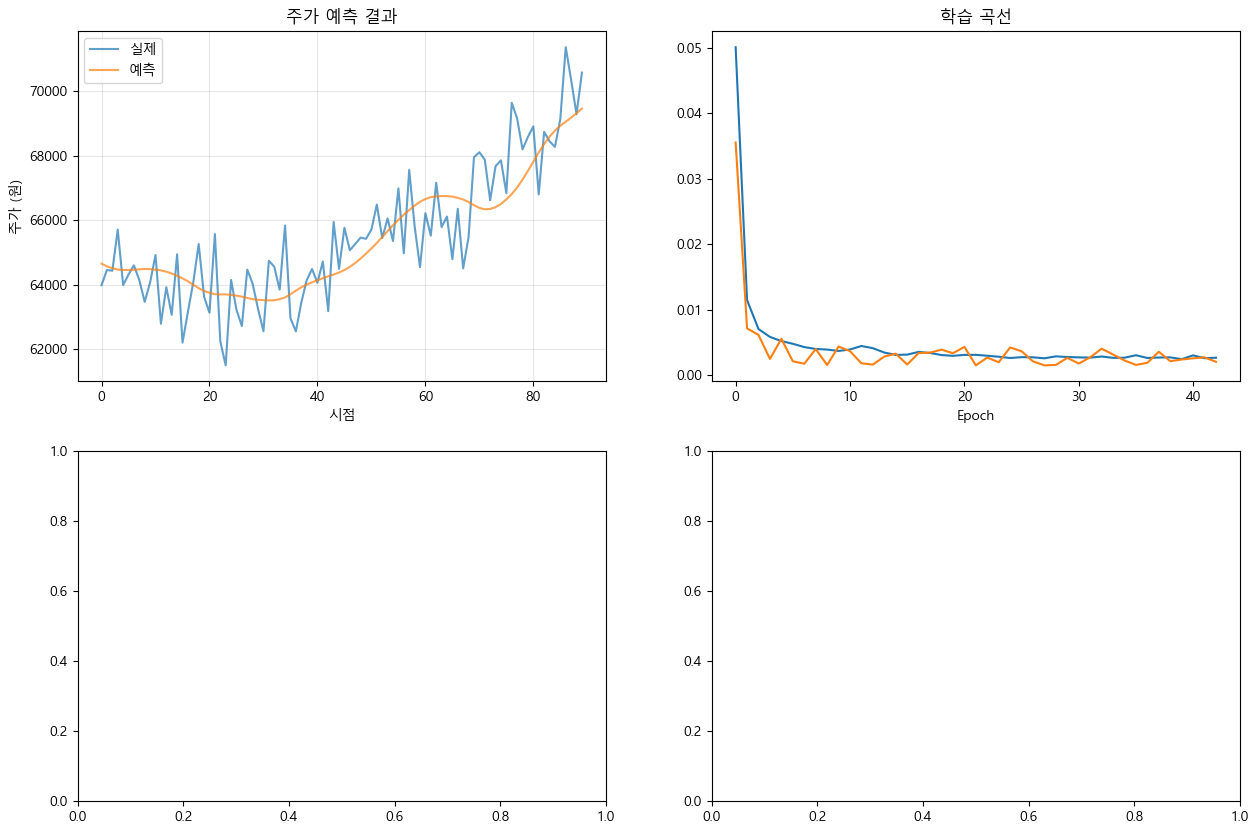

In [18]:
# lstm_stock_prediction.py
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
import numpy as np
import pandas as pd
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("="*80)
print("LSTM 주가 예측 시스템 (GPU 가속)")
print("="*80)

# GPU 설정
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"\nGPU 사용: {gpus[0].name}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

# 1. 데이터 로드 함수
def load_stock_data(ticker='005930', days=1000):
    """
    실제로는 DB에서 로드하지만, 여기서는 샘플 데이터 생성
    호영님의 MySQL DB 연결 코드로 대체 가능
    """
    np.random.seed(42)
    dates = pd.date_range(end=datetime.now(), periods=days, freq='D')

    # 실제 같은 주가 패턴 생성
    trend = np.linspace(50000, 70000, days)
    seasonality = 5000 * np.sin(np.linspace(0, 8*np.pi, days))
    noise = np.random.normal(0, 1000, days)
    close = trend + seasonality + noise

    df = pd.DataFrame({
        'date': dates,
        'close': close,
        'volume': np.random.randint(1000000, 10000000, days)
    })

    return df

# 2. 시퀀스 생성
def create_sequences(data, seq_length, pred_length=1):
    """시계열 시퀀스 생성"""
    X, y = [], []

    for i in range(len(data) - seq_length - pred_length + 1):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length:i+seq_length+pred_length])

    return np.array(X), np.array(y)

# 3. 데이터 준비
print("\n" + "="*80)
print("1. 데이터 준비")
print("="*80)

df = load_stock_data(days=1000)
print(f"데이터: {len(df)}일")
print(f"기간: {df['date'].min().date()} ~ {df['date'].max().date()}")
print(f"종가: {df['close'].min():.0f} ~ {df['close'].max():.0f}")

# 정규화
scaler = MinMaxScaler()
scaled_close = scaler.fit_transform(df[['close']]).flatten()

# 데이터 분할 (70% 훈련, 15% 검증, 15% 테스트)
train_size = int(len(scaled_close) * 0.7)
val_size = int(len(scaled_close) * 0.15)

train_data = scaled_close[:train_size]
val_data = scaled_close[train_size:train_size+val_size]
test_data = scaled_close[train_size+val_size:]

# 시퀀스 생성
SEQ_LENGTH = 60  # 60일 데이터로 예측
PRED_LENGTH = 1  # 1일 후 예측

X_train, y_train = create_sequences(train_data, SEQ_LENGTH, PRED_LENGTH)
X_val, y_val = create_sequences(val_data, SEQ_LENGTH, PRED_LENGTH)
X_test, y_test = create_sequences(test_data, SEQ_LENGTH, PRED_LENGTH)

# Reshape
X_train = X_train.reshape(-1, SEQ_LENGTH, 1)
X_val = X_val.reshape(-1, SEQ_LENGTH, 1)
X_test = X_test.reshape(-1, SEQ_LENGTH, 1)

print(f"\n훈련: {X_train.shape}, 검증: {X_val.shape}, 테스트: {X_test.shape}")

# 4. 모델 구축
print("\n" + "="*80)
print("2. LSTM 모델 구축")
print("="*80)

model = tf.keras.Sequential([
    # LSTM Layer 1
    tf.keras.layers.LSTM(
        units=128,
        return_sequences=True,
        input_shape=(SEQ_LENGTH, 1)
    ),
    tf.keras.layers.Dropout(0.2),

    # LSTM Layer 2
    tf.keras.layers.LSTM(
        units=64,
        return_sequences=True
    ),
    tf.keras.layers.Dropout(0.2),

    # LSTM Layer 3
    tf.keras.layers.LSTM(
        units=32,
        return_sequences=False
    ),
    tf.keras.layers.Dropout(0.2),

    # Dense Layers
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(PRED_LENGTH)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()

# 5. 콜백 설정
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=0.00001,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_model.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )
]

# 6. 학습
print("\n" + "="*80)
print("3. 모델 학습 (GPU)")
print("="*80)

start_time = datetime.now()

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

elapsed = (datetime.now() - start_time).total_seconds()
print(f"\n학습 완료: {elapsed:.2f}초 ({elapsed/60:.1f}분)")

# 7. 평가
print("\n" + "="*80)
print("4. 모델 평가")
print("="*80)

test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"테스트 Loss: {test_loss:.6f}")
print(f"테스트 MAE: {test_mae:.6f}")

# 8. 예측
predictions = model.predict(X_test, verbose=0)

# 역정규화
pred_actual = scaler.inverse_transform(predictions.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# RMSE, MAPE 계산
rmse = np.sqrt(np.mean((pred_actual - y_test_actual)**2))
mape = np.mean(np.abs((y_test_actual - pred_actual) / y_test_actual)) * 100

print(f"\nRMSE: {rmse:.2f}원")
print(f"MAPE: {mape:.2f}%")

# 9. 결과 저장
results = pd.DataFrame({
    'actual': y_test_actual.flatten(),
    'predicted': pred_actual.flatten(),
    'error': y_test_actual.flatten() - pred_actual.flatten(),
    'error_pct': ((y_test_actual.flatten() - pred_actual.flatten()) / y_test_actual.flatten() * 100)
})

print("\n최근 10일 예측:")
print(results.tail(10).to_string(index=False))

# 10. 시각화
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 예측 vs 실제
axes[0, 0].plot(y_test_actual, label='실제', alpha=0.7)
axes[0, 0].plot(pred_actual, label='예측', alpha=0.7)
axes[0, 0].set_title('주가 예측 결과')
axes[0, 0].set_xlabel('시점')
axes[0, 0].set_ylabel('주가 (원)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Loss 곡선
axes[0, 1].plot(history.history['loss'], label='훈련 Loss')
axes[0, 1].plot(history.history['val_loss'], label='검증 Loss')
axes[0, 1].set_title('학습 곡선')
axes[0, 1].set_xlabel('Epoch')
axe